In [ ]:
! pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.1 MB/s eta 0:00:00


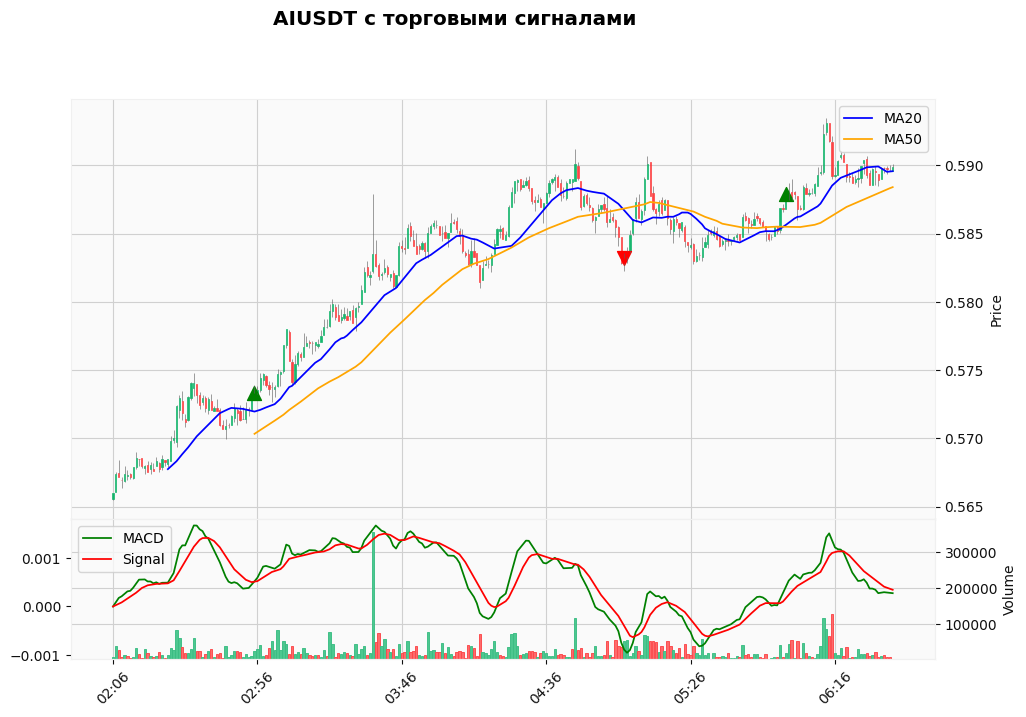

Общая процентная выручка: 1.73%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
import numpy as np

# Загрузка данных из CSV
data = pd.read_csv('/content/AIUSDT_1721014562180.csv')

# Преобразование времени в миллисекундах в формат даты
data['Time'] = pd.to_datetime(data['Time'], unit='ms')
data.set_index('Time', inplace=True)

# Вычисление MA20 и MA50
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

# Вычисление MACD и сигнальной линии
data['EMA12'] = data['Close'].ewm(span=12, adjust=False).mean()
data['EMA26'] = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = data['EMA12'] - data['EMA26']
data['Signal_line'] = data['MACD'].ewm(span=9, adjust=False).mean()

# Инициализация столбцов
data['Trading_Signal'] = 0
data['total_return'] = 0.0

# Генерация торговых сигналов и расчет процентной выручки
entry_price = 0
position_open = 0

for i in range(1, len(data)):
    if (data['MA20'].iloc[i] > data['MA50'].iloc[i] and
        data['MACD'].iloc[i] > data['Signal_line'].iloc[i] and position_open == 0):
        data.loc[data.index[i], 'Trading_Signal'] = 1
        entry_price = data['Close'].iloc[i]
        position_open += 1
    elif (data['MA20'].iloc[i] < data['MA50'].iloc[i] and
          data['MACD'].iloc[i] < data['Signal_line'].iloc[i] and position_open > 0):
        data.loc[data.index[i], 'Trading_Signal'] = -1
        exit_price = data['Close'].iloc[i]
        data.loc[data.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open -= 1

# Итоговая процентная выручка
total_return = data['total_return'].sum()

# Подготовка к отображению
ap = [
    mpf.make_addplot(data['MA20'], color='blue', label='MA20'),
    mpf.make_addplot(data['MA50'], color='orange', label='MA50'),
    mpf.make_addplot(data['MACD'], panel=1, color='green', label='MACD'),
    mpf.make_addplot(data['Signal_line'], panel=1, color='red', label='Signal'),
    mpf.make_addplot(data['Close'].where(data['Trading_Signal'] == 1, np.nan), scatter=True, markersize=100, marker='^', color='g', panel=0),
    mpf.make_addplot(data['Close'].where(data['Trading_Signal'] == -1, np.nan), scatter=True, markersize=100, marker='v', color='r', panel=0),
]

mpf.plot(data, type='candle', addplot=ap, volume=True,
         style='yahoo', title='AIUSDT с торговыми сигналами',
         figsize=(12, 8), panel_ratios=(3, 1))

print(f"Общая процентная выручка: {total_return:.2f}%")


Добавим прогноизрование цены закрытия с помощью авторегрессора Prophet

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcufxz_d6/s0totrxw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcufxz_d6/z7mjm4mb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=92451', 'data', 'file=/tmp/tmpcufxz_d6/s0totrxw.json', 'init=/tmp/tmpcufxz_d6/z7mjm4mb.json', 'output', 'file=/tmp/tmpcufxz_d6/prophet_modelpiqyymyq/prophet_model-20240909125500.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:55:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:55:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
<ipython-input-68-24958012b824>:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffi

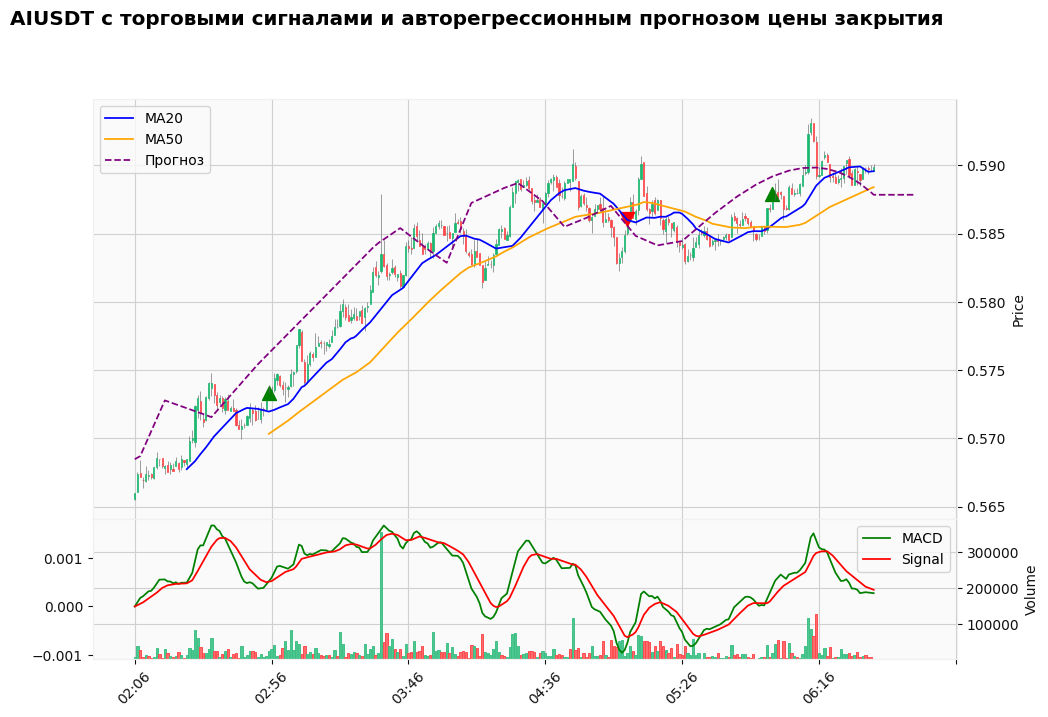

RMSE: 0.00
R squared: 0.94
Общая процентная выручка: 2.23%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Загрузка данных из CSV
data = pd.read_csv('/content/AIUSDT_1721014562180.csv')

# Преобразование времени в миллисекундах в формат даты
data['Time'] = pd.to_datetime(data['Time'], unit='ms')
data.set_index('Time', inplace=True)

# Вычисление MA20 и MA50
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

# Вычисление MACD и сигнальной линии
data['EMA12'] = data['Close'].ewm(span=12, adjust=False).mean()
data['EMA26'] = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = data['EMA12'] - data['EMA26']
data['Signal_line'] = data['MACD'].ewm(span=9, adjust=False).mean()

# Подготовка данных для Prophet
df = data[['Close']].reset_index().rename(columns={'Time': 'ds', 'Close': 'y'})

# Инициализация и обучение модели Prophet
model = Prophet(daily_seasonality=True, weekly_seasonality=False)
model.fit(df)

# Создание данных для прогнозирования
future = model.make_future_dataframe(periods=15, freq='T')
forecast = model.predict(future)

# Объединение прогноза с исходными данными и сдвиг прогноза на 15 минут назад
forecast.set_index('ds', inplace=True)
forecast['yhat'] = forecast['yhat'].shift(-15)
combined_data = pd.concat([data, forecast[['yhat']]], axis=1)
combined_data['yhat'].fillna(method='ffill', inplace=True)

# Инициализация столбцов
combined_data['Trading_Signal'] = 0
combined_data['total_return'] = 0.0

# Генерация торговых сигналов и расчет процентной выручки
entry_price = 0
position_open = False

for i in range(1, len(combined_data)):
    if (combined_data['MA20'].iloc[i] > combined_data['MA50'].iloc[i] and
        combined_data['MACD'].iloc[i] > combined_data['Signal_line'].iloc[i] and
        combined_data['yhat'].iloc[i] > combined_data['Close'].iloc[i] and not position_open):

        combined_data.loc[combined_data.index[i], 'Trading_Signal'] = 1
        entry_price = combined_data['Close'].iloc[i]
        position_open = True

    elif (combined_data['MA20'].iloc[i] < combined_data['MA50'].iloc[i] and
          combined_data['MACD'].iloc[i] < combined_data['Signal_line'].iloc[i] and
          combined_data['yhat'].iloc[i] < combined_data['Close'].iloc[i] and position_open):

        combined_data.loc[combined_data.index[i], 'Trading_Signal'] = -1
        exit_price = combined_data['Close'].iloc[i]
        combined_data.loc[combined_data.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open = False

# Итоговая процентная выручка
total_return = combined_data['total_return'].sum()

# Подготовка к отображению
ap = [
    mpf.make_addplot(combined_data['MA20'], color='blue', label='MA20'),
    mpf.make_addplot(combined_data['MA50'], color='orange', label='MA50'),
    mpf.make_addplot(combined_data['MACD'], panel=1, color='green', label='MACD'),
    mpf.make_addplot(combined_data['Signal_line'], panel=1, color='red', label='Signal'),
    mpf.make_addplot(combined_data['yhat'], color='purple', linestyle='--', label='Прогноз'),
    mpf.make_addplot(combined_data['Close'].where(combined_data['Trading_Signal'] == 1, np.nan), scatter=True, markersize=100, marker='^', color='g', panel=0),
    mpf.make_addplot(combined_data['Close'].where(combined_data['Trading_Signal'] == -1, np.nan), scatter=True, markersize=100, marker='v', color='r', panel=0),
]

mpf.plot(combined_data, type='candle', addplot=ap, volume=True,
         style='yahoo', title='AIUSDT с торговыми сигналами и авторегрессионным прогнозом цены закрытия',
         figsize=(12, 8), panel_ratios=(3, 1))
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
print(f"Общая процентная выручка: {total_return:.2f}%")


Поменяем авторегрессор на XGBoost, предсказывающий значение по признаковому описанию

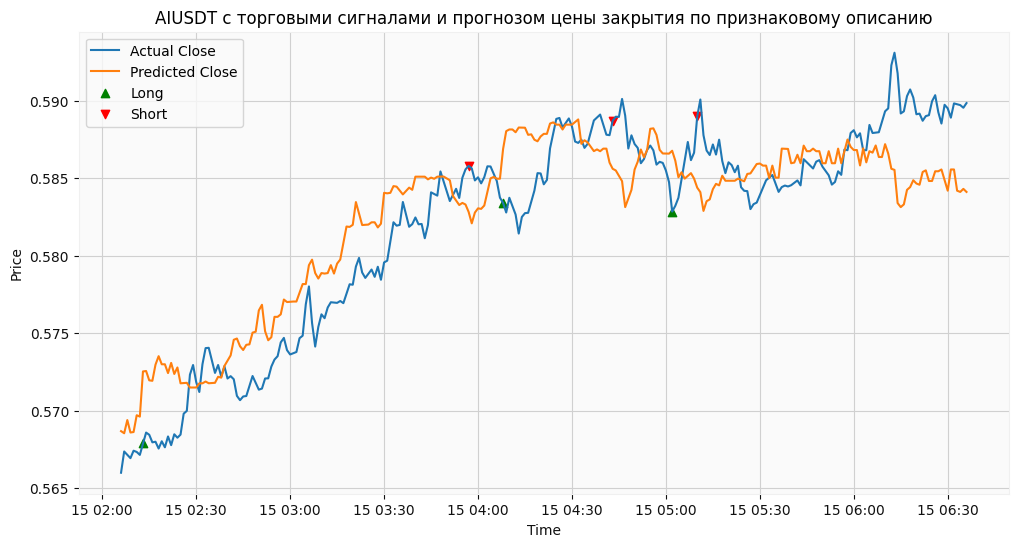

RMSE: 0.00
R squared: 0.94
Общая процентная выручка: 5.12%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from prophet import Prophet

shift = 15
symbol = 'AIUSDT'

# Загрузка данных из CSV
df = pd.read_csv('/content/AIUSDT_1721014562180.csv')

# Преобразование времени в миллисекундах в формат даты
df['Time'] = pd.to_datetime(df['Time'], unit='ms')
df.set_index('Time', inplace=True)

# Создание признаков
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['RSI'] = 100 - (100 / (1 + df['Close'].diff(1).clip(lower=0).rolling(14).mean() /
                          df['Close'].diff(1).clip(upper=0).abs().rolling(14).mean()))

# Подготовка признаков и целевой переменной
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA50', 'MA20', 'RSI']
X = df[features]
y = df['Close'].shift(-shift).dropna()
X = X.iloc[:-shift]

# Разделение данных на обучающую и тестовую выборки
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение и прогнозирование XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
predictions_xgb = xgb_model.predict(scaler.transform(df[features]))
df['Predicted_Close'] = np.nan
df.iloc[:, df.columns.get_loc('Predicted_Close')] = predictions_xgb

# Генерация торговых сигналов и расчет процентной выручки
position_open = False
df['Signal'] = 0
df['total_return'] = 0.0  # Новый столбец для выручки

entry_price = 0

for i in range(1, len(df)):
    if df['Predicted_Close'].iloc[i] > df['Close'].iloc[i] * 1.005 and not position_open:
        df.loc[df.index[i], 'Signal'] = 1
        entry_price = df['Close'].iloc[i]
        position_open = True
    elif df['Predicted_Close'].iloc[i] < df['Close'].iloc[i] * 0.995 and position_open:
        df.loc[df.index[i], 'Signal'] = -1
        exit_price = df['Close'].iloc[i]
        df.loc[df.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open = False

# Итоговая процентная выручка
total_return = df['total_return'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Close')
plt.plot(df.index, df['Predicted_Close'], label='Predicted Close')
plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], color='green', label='Long', marker='^')
plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], color='red', label='Short', marker='v')
plt.title('AIUSDT с торговыми сигналами и прогнозом цены закрытия по признаковому описанию')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Расчет метрик RMSE и R squared
true_values = df['Close'].shift(-15).dropna()
predicted_values = df['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]


# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)



#print(f"Mean Squared Error: {mean_squared_error(y_test_shifted, y_pred)}")
#print(f"R-squared Score: {r2_score(y_test_shifted, y_pred)}")

# Эффективность стратегии
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
print(f"Общая процентная выручка: {total_return:.2f}%")



Перенесем последний код в функцию для  более удобного вызова при получении данных  от внешнего API

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from prophet import Prophet

def analyze_data(df, symbol='BTCUSD_PERP', shift=15):
    # Создание признаков
    # Создание признаков
    df['MA50'] = df['Close'].rolling(window=50).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['RSI'] = 100 - (100 / (1 + df['Close'].diff(1).clip(lower=0).rolling(14).mean() /
                          df['Close'].diff(1).clip(upper=0).abs().rolling(14).mean()))

    # Подготовка признаков и целевой переменной
    features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA50', 'MA20', 'RSI']
    X = df[features]
    y = df['Close'].shift(-shift).dropna()
    X = X.iloc[:-shift]

    # Разделение данных на обучающую и тестовую выборки
    train_size = int(0.8 * len(X))
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Масштабирование признаков
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Обучение и прогнозирование XGBoost
    xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    xgb_model.fit(X_train_scaled, y_train)
    predictions_xgb = xgb_model.predict(scaler.transform(df[features]))
    df['Predicted_Close'] = np.nan
    df.iloc[:, df.columns.get_loc('Predicted_Close')] = predictions_xgb

    # Генерация торговых сигналов и расчет процентной выручки
    position_open = False
    df['Signal'] = 0
    df['total_return'] = 0.0  # Новый столбец для выручки

    entry_price = 0

    for i in range(1, len(df)):
        if df['Predicted_Close'].iloc[i] > df['Close'].iloc[i] * 1.005 and not position_open:
            df.loc[df.index[i], 'Signal'] = 1
            entry_price = df['Close'].iloc[i]
            position_open = True
        elif df['Predicted_Close'].iloc[i] < df['Close'].iloc[i] * 0.995 and position_open:
            df.loc[df.index[i], 'Signal'] = -1
            exit_price = df['Close'].iloc[i]
            df.loc[df.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
            position_open = False

    # Итоговая процентная выручка
    total_return = df['total_return'].sum()

    # Построение графика
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Close'], label='Actual Close')
    plt.plot(df.index, df['Predicted_Close'], label='Predicted Close')
    plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], color='green', label='Long', marker='^')
    plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], color='red', label='Short', marker='v')
    plt.title('AIUSDT с торговыми сигналами и прогнозом цены закрытия по признаковому описанию')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

    # Расчет метрик RMSE и R squared
    true_values = df['Close'].shift(-15).dropna()
    predicted_values = df['Predicted_Close'].dropna()

    # Убедимся, что длины совпадают
    min_length = min(len(true_values), len(predicted_values))
    true_values = true_values.iloc[:min_length]
    predicted_values = predicted_values.iloc[:min_length]


    # Расчет метрик RMSE и R squared
    rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
    r2 = r2_score(true_values, predicted_values)

    # Эффективность стратегии
    print(f"RMSE: {rmse:.2f}")
    print(f"R squared: {r2:.2f}")
    print(f"Общая процентная выручка: {total_return:.2f}%")


In [ ]:
import requests
def get_data(symbol='BTCUSD_PERP', interval='1m'):
    url = 'https://dapi.binance.com/dapi/v1/klines'
    params = {
        'symbol': symbol,
        'interval': interval
    }
    headers = {
        'Content-Type': 'application/json'
    }

    response = requests.get(url, headers=headers, params=params)

    # Проверка и вывод данных
    if response.status_code == 200:
        data = response.json()
        return data
    else:
        print(f"Ошибка: {response.status_code}, Сообщение: {response.text}")

In [ ]:
import pandas as pd
def preprocess_data(data):
    df = pd.DataFrame(data, columns=['Time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore'])
    # Преобразование строковых числовых данных в числовые типы
    df['Open'] = df['Open'].astype(float)
    df['High'] = df['High'].astype(float)
    df['Low'] = df['Low'].astype(float)
    df['Close'] = df['Close'].astype(float)
    df['Volume'] = df['Volume'].astype(int)
    df['Quote asset volume'] = df['Quote asset volume'].astype(float)
    df['Number of trades'] = df['Number of trades'].astype(int)
    df['Taker buy base asset volume'] = df['Taker buy base asset volume'].astype(float)
    df['Taker buy quote asset volume'] = df['Taker buy quote asset volume'].astype(float)
    df['Time'] = pd.to_datetime(df['Time'], unit='ms')
    df.set_index('Time', inplace=True)
    return df

In [ ]:
df = preprocess_data(get_data(symbol='BTCUSD_PERP'))
analyze_data(df, symbol='BTCUSD_PERP')

Ошибка: 451, Сообщение: {
  "code": 0,
  "msg": "Service unavailable from a restricted location according to 'b. Eligibility' in https://www.binance.com/en/terms. Please contact customer service if you believe you received this message in error."
}


ValueError: Found array with 0 sample(s) (shape=(0, 8)) while a minimum of 1 is required by StandardScaler.

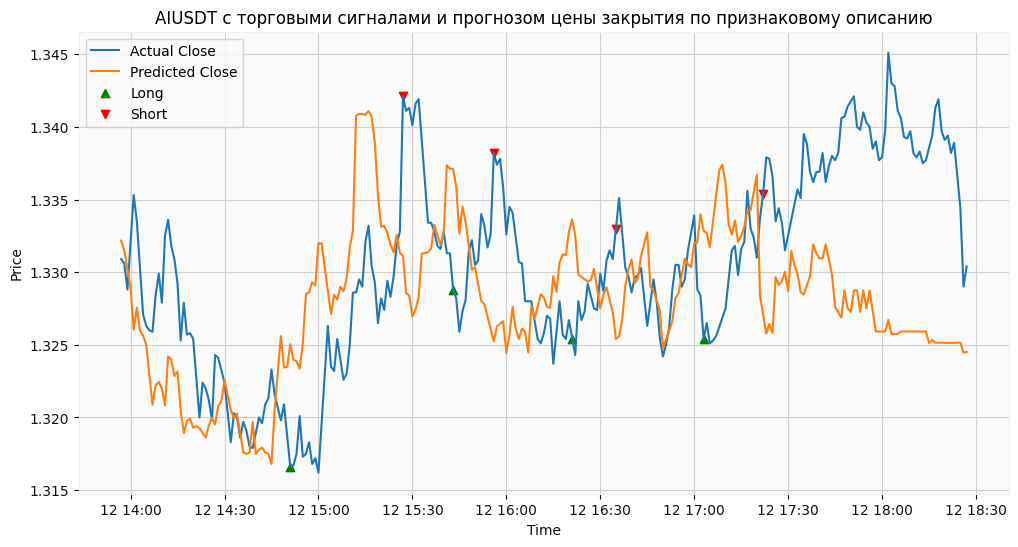

RMSE: 0.01
R squared: 0.44
Общая процентная выручка: 3.97%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from prophet import Prophet

shift = 15
symbol = 'ARKMUSDT'

# Загрузка данных из CSV
df = pd.read_csv('/content/ARKMUSDT_1720798047091.csv')

# Преобразование времени в миллисекундах в формат даты
df['Time'] = pd.to_datetime(df['Time'], unit='ms')
df.set_index('Time', inplace=True)

# Создание признаков
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['RSI'] = 100 - (100 / (1 + df['Close'].diff(1).clip(lower=0).rolling(14).mean() /
                          df['Close'].diff(1).clip(upper=0).abs().rolling(14).mean()))

# Подготовка признаков и целевой переменной
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA50', 'MA20', 'RSI']
X = df[features]
y = df['Close'].shift(-shift).dropna()
X = X.iloc[:-shift]

# Разделение данных на обучающую и тестовую выборки
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение и прогнозирование XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
predictions_xgb = xgb_model.predict(scaler.transform(df[features]))
df['Predicted_Close'] = np.nan
df.iloc[:, df.columns.get_loc('Predicted_Close')] = predictions_xgb

# Генерация торговых сигналов и расчет процентной выручки
position_open = False
df['Signal'] = 0
df['total_return'] = 0.0  # Новый столбец для выручки

entry_price = 0

for i in range(1, len(df)):
    if df['Predicted_Close'].iloc[i] > df['Close'].iloc[i] * 1.005 and not position_open:
        df.loc[df.index[i], 'Signal'] = 1
        entry_price = df['Close'].iloc[i]
        position_open = True
    elif df['Predicted_Close'].iloc[i] < df['Close'].iloc[i] * 0.995 and position_open:
        df.loc[df.index[i], 'Signal'] = -1
        exit_price = df['Close'].iloc[i]
        df.loc[df.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open = False

# Итоговая процентная выручка
total_return = df['total_return'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Close')
plt.plot(df.index, df['Predicted_Close'], label='Predicted Close')
plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], color='green', label='Long', marker='^')
plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], color='red', label='Short', marker='v')
plt.title('AIUSDT с торговыми сигналами и прогнозом цены закрытия по признаковому описанию')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Расчет метрик RMSE и R squared
true_values = df['Close'].shift(-15).dropna()
predicted_values = df['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]


# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)



#print(f"Mean Squared Error: {mean_squared_error(y_test_shifted, y_pred)}")
#print(f"R-squared Score: {r2_score(y_test_shifted, y_pred)}")

# Эффективность стратегии
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
print(f"Общая процентная выручка: {total_return:.2f}%")



<ipython-input-51-9d8c9bd091cf>:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Predicted_Close'] = np.nan


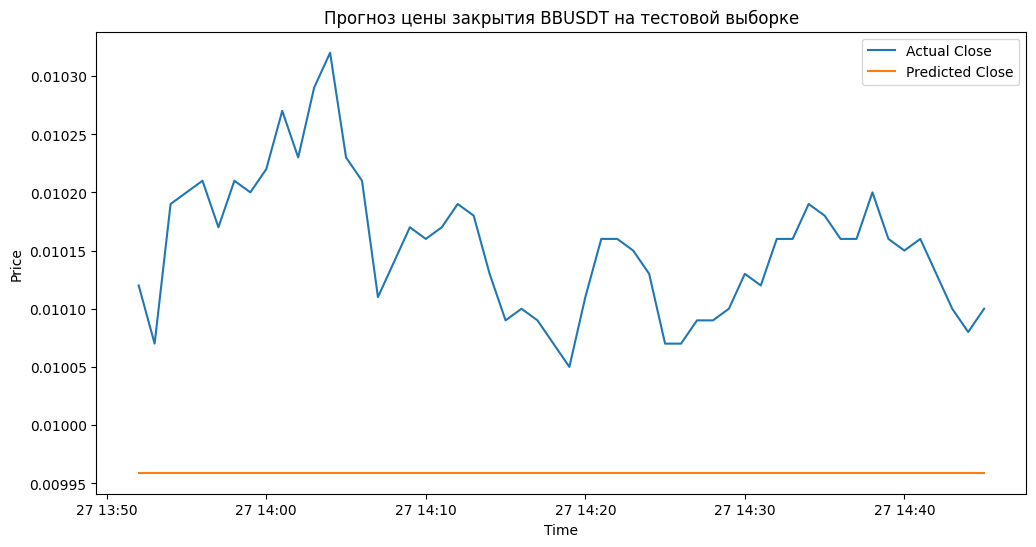

RMSE: 0.00
R squared: -11.36


'\n\npredictions_xgb = xgb_model.predict(scaler.transform(df[features]))\ndf[\'Predicted_Close\'] = np.nan\n\n\ndf.iloc[:, df.columns.get_loc(\'Predicted_Close\')] = predictions_xgb\n\n# Генерация торговых сигналов и расчет процентной выручки\nposition_open = False\ndf[\'Signal\'] = 0\ndf[\'total_return\'] = 0.0  # Новый столбец для выручки\n\nentry_price = 0\n\nfor i in range(1, len(df)):\n    if df[\'Predicted_Close\'].iloc[i] > df[\'Close\'].iloc[i] and not position_open:\n        df.loc[df.index[i], \'Signal\'] = 1\n        entry_price = df[\'Close\'].iloc[i]\n        position_open = True\n    elif df[\'Predicted_Close\'].iloc[i] < df[\'Close\'].iloc[i] and position_open:\n        df.loc[df.index[i], \'Signal\'] = -1\n        exit_price = df[\'Close\'].iloc[i]\n        df.loc[df.index[i], \'total_return\'] = (exit_price - entry_price) / entry_price * 100\n        position_open = False\n\n# Итоговая процентная выручка\ntotal_return = df[\'total_return\'].sum()\n\n# Построение график

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from prophet import Prophet

shift = 2
symbol = 'BBUSDT'

# Загрузка данных из CSV
df = pd.read_csv('/content/STMXUSDT_1722080875736.csv')

# Преобразование времени в миллисекундах в формат даты
df['Time'] = pd.to_datetime(df['Time'], unit='ms')
df.set_index('Time', inplace=True)

# Создание признаков
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['RSI'] = 100 - (100 / (1 + df['Close'].diff(1).clip(lower=0).rolling(14).mean() /
                          df['Close'].diff(1).clip(upper=0).abs().rolling(14).mean()))

# Подготовка признаков и целевой переменной
features = ['Open', 'High', 'Low', 'Volume']#, 'Close', 'MA50', 'MA20', 'RSI']
X = df[features]
y = df['Close'].shift(-shift).dropna()
X = X.iloc[:-shift]

# Разделение данных на обучающую и тестовую выборки
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение и оценка прогнозирование XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
predictions_xgb_test = xgb_model.predict(scaler.transform(X_test[features]))
X_test['Predicted_Close'] = np.nan


X_test.iloc[:, X_test.columns.get_loc('Predicted_Close')] = predictions_xgb_test


# Расчет метрик RMSE и R squared
true_values = y_test.dropna()
predicted_values = X_test['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)




# Построение графика прогноза на тестовой выборке
plt.figure(figsize=(12, 6))
plt.plot(true_values.index, true_values, label='Actual Close')
plt.plot(predicted_values.index, predicted_values, label='Predicted Close')
plt.title(f"Прогноз цены закрытия {symbol} на тестовой выборке")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


# Эффективность модели
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
'''

predictions_xgb = xgb_model.predict(scaler.transform(df[features]))
df['Predicted_Close'] = np.nan


df.iloc[:, df.columns.get_loc('Predicted_Close')] = predictions_xgb

# Генерация торговых сигналов и расчет процентной выручки
position_open = False
df['Signal'] = 0
df['total_return'] = 0.0  # Новый столбец для выручки

entry_price = 0

for i in range(1, len(df)):
    if df['Predicted_Close'].iloc[i] > df['Close'].iloc[i] and not position_open:
        df.loc[df.index[i], 'Signal'] = 1
        entry_price = df['Close'].iloc[i]
        position_open = True
    elif df['Predicted_Close'].iloc[i] < df['Close'].iloc[i] and position_open:
        df.loc[df.index[i], 'Signal'] = -1
        exit_price = df['Close'].iloc[i]
        df.loc[df.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open = False

# Итоговая процентная выручка
total_return = df['total_return'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Close')
plt.plot(df.index, df['Predicted_Close'], label='Predicted Close')
plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], color='green', label='Long', marker='^')
plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], color='red', label='Short', marker='v')
plt.title(f'{symbol} с торговыми сигналами и прогнозом цены закрытия по признаковому описанию')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Расчет метрик RMSE и R squared
true_values = df['Close'].shift(-shift).dropna()
predicted_values = df['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)



# Эффективность стратегии
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
print(f"Общая процентная выручка: {total_return:.2f}%")

'''


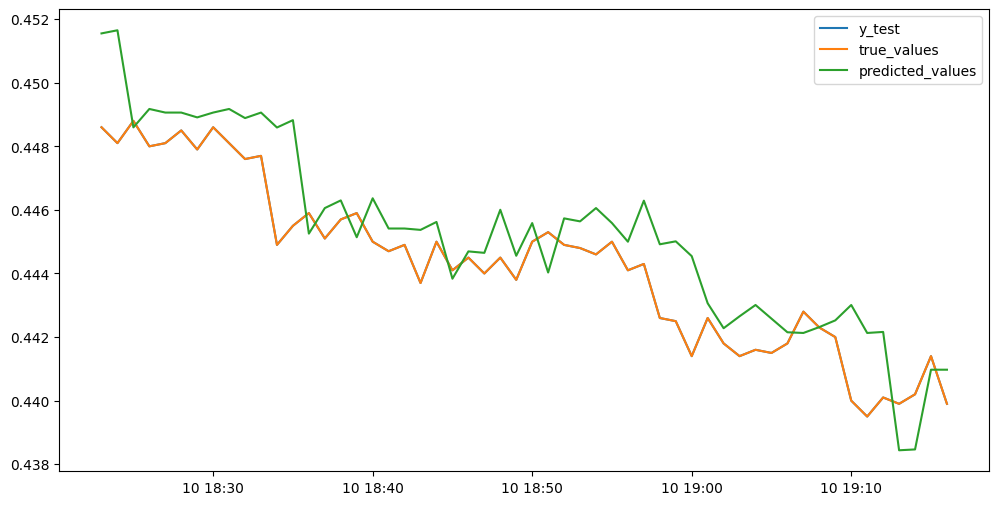

In [49]:
plt.figure(figsize=(12, 6))
#plt.plot(X_test.index, X_test['Close'], label='X_test')
plt.plot(y_test.index, y_test, label='y_test')
plt.plot(true_values.index, true_values, label='true_values')
plt.plot(predicted_values.index, predicted_values, label='predicted_values')
plt.legend()
plt.show()

In [31]:
true_values

,Close
Time,
2024-07-25 16:41:00,29.972
2024-07-25 16:42:00,29.946
2024-07-25 16:43:00,29.863
2024-07-25 16:44:00,29.800
2024-07-25 16:45:00,29.845
2024-07-25 16:46:00,29.865
2024-07-25 16:47:00,29.861
2024-07-25 16:48:00,29.917
2024-07-25 16:49:00,29.918


<ipython-input-27-79b127846f8b>:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Predicted_Close'] = np.nan


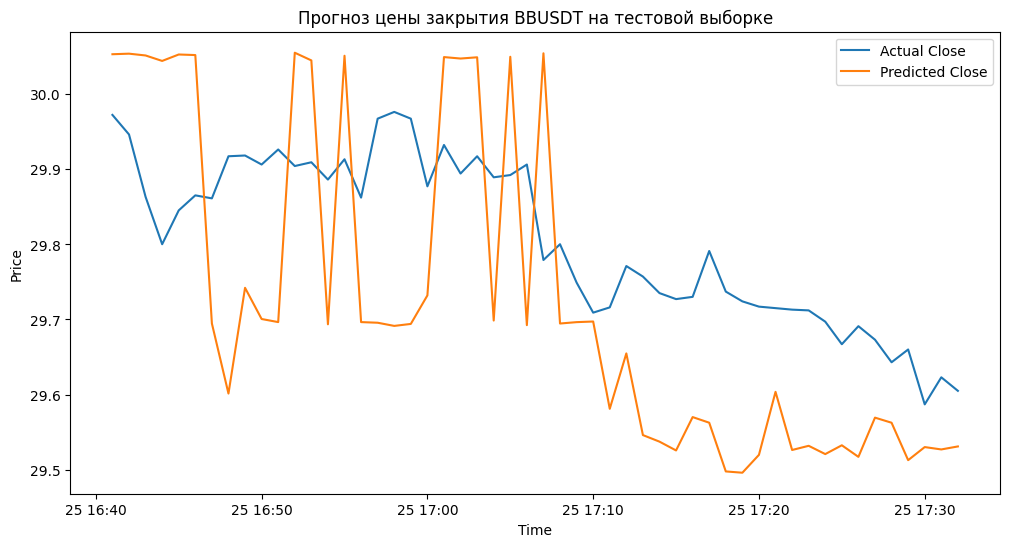

RMSE: 0.18
R squared: -1.71


'\npredictions_xgb = xgb_model.predict(scaler.transform(df[features]))\ndf[\'Predicted_Close\'] = np.nan\n\n\ndf.iloc[:, df.columns.get_loc(\'Predicted_Close\')] = predictions_xgb\n\n# Генерация торговых сигналов и расчет процентной выручки\nposition_open = False\ndf[\'Signal\'] = 0\ndf[\'total_return\'] = 0.0  # Новый столбец для выручки\n\nentry_price = 0\n\nfor i in range(1, len(df)):\n    if df[\'Predicted_Close\'].iloc[i] > df[\'Close\'].iloc[i] and not position_open:\n        df.loc[df.index[i], \'Signal\'] = 1\n        entry_price = df[\'Close\'].iloc[i]\n        position_open = True\n    elif df[\'Predicted_Close\'].iloc[i] < df[\'Close\'].iloc[i] and position_open:\n        df.loc[df.index[i], \'Signal\'] = -1\n        exit_price = df[\'Close\'].iloc[i]\n        df.loc[df.index[i], \'total_return\'] = (exit_price - entry_price) / entry_price * 100\n        position_open = False\n\n# Итоговая процентная выручка\ntotal_return = df[\'total_return\'].sum()\n\n# Построение графика\

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from prophet import Prophet

shift = 2
symbol = 'BBUSDT'

# Загрузка данных из CSV
df = pd.read_csv('/content/ARUSDT_1721918198026.csv')

# Преобразование времени в миллисекундах в формат даты
df['Time'] = pd.to_datetime(df['Time'], unit='ms')
df.set_index('Time', inplace=True)

# Создание признаков
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['RSI'] = 100 - (100 / (1 + df['Close'].diff(1).clip(lower=0).rolling(14).mean() /
                          df['Close'].diff(1).clip(upper=0).abs().rolling(14).mean()))

# Подготовка признаков и целевой переменной
features = ['Open', 'High', 'Low', 'Volume', 'Close', 'MA50', 'MA20', 'RSI']
X = df[features]
y = df['Close'].shift(-shift).dropna()
X = X.iloc[:-shift]

# Разделение данных на обучающую и тестовую выборки
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение и оценка прогнозирование XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
predictions_xgb_test = xgb_model.predict(scaler.transform(X_test[features]))
X_test['Predicted_Close'] = np.nan


X_test.iloc[:, X_test.columns.get_loc('Predicted_Close')] = predictions_xgb_test


# Расчет метрик RMSE и R squared
true_values = y_test.shift(-shift).dropna()
predicted_values = X_test['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)

# Построение графика прогноза на тестовой выборке
plt.figure(figsize=(12, 6))
plt.plot(true_values.index, true_values, label='Actual Close')
plt.plot(predicted_values.index, predicted_values, label='Predicted Close')
plt.title(f"Прогноз цены закрытия {symbol} на тестовой выборке")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


# Эффективность модели
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")

'''
predictions_xgb = xgb_model.predict(scaler.transform(df[features]))
df['Predicted_Close'] = np.nan


df.iloc[:, df.columns.get_loc('Predicted_Close')] = predictions_xgb

# Генерация торговых сигналов и расчет процентной выручки
position_open = False
df['Signal'] = 0
df['total_return'] = 0.0  # Новый столбец для выручки

entry_price = 0

for i in range(1, len(df)):
    if df['Predicted_Close'].iloc[i] > df['Close'].iloc[i] and not position_open:
        df.loc[df.index[i], 'Signal'] = 1
        entry_price = df['Close'].iloc[i]
        position_open = True
    elif df['Predicted_Close'].iloc[i] < df['Close'].iloc[i] and position_open:
        df.loc[df.index[i], 'Signal'] = -1
        exit_price = df['Close'].iloc[i]
        df.loc[df.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open = False

# Итоговая процентная выручка
total_return = df['total_return'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Close')
plt.plot(df.index, df['Predicted_Close'], label='Predicted Close')
plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], color='green', label='Long', marker='^')
plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], color='red', label='Short', marker='v')
plt.title(f'{symbol} с торговыми сигналами и прогнозом цены закрытия по признаковому описанию')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Расчет метрик RMSE и R squared
true_values = df['Close'].shift(-shift).dropna()
predicted_values = df['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)



# Эффективность стратегии
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
print(f"Общая процентная выручка: {total_return:.2f}%")

'''


Минимальное значение Close: 0.4395


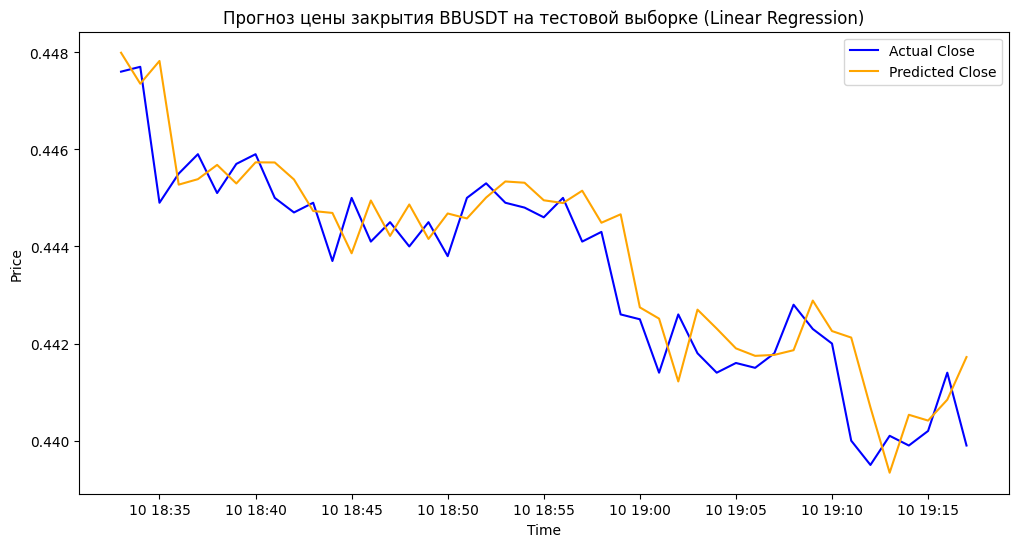

RMSE: 0.00
R squared: 0.80


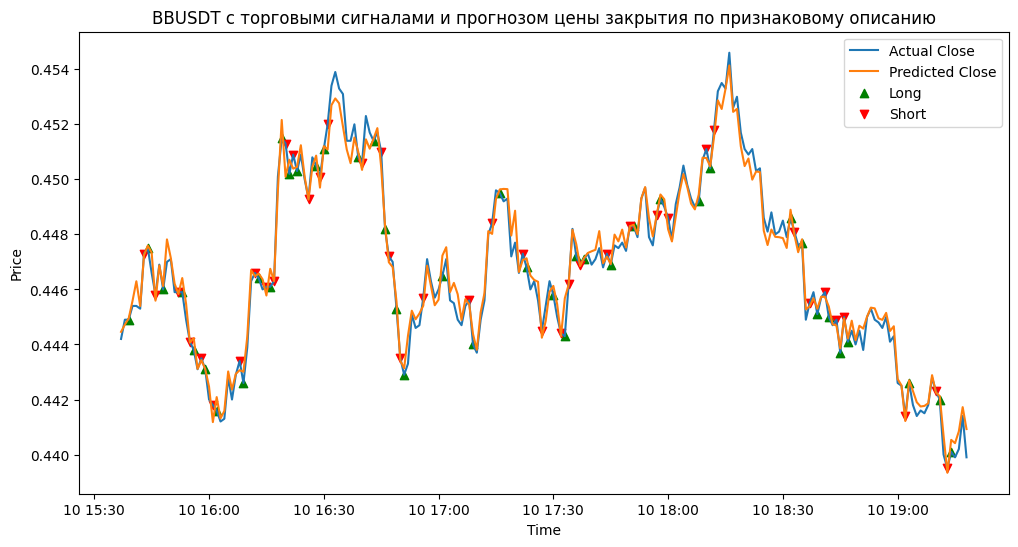

RMSE: 0.00
R squared: 0.91
Общая процентная выручка: -0.00%


In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

shift = 1  # Устанавливаем значение shift на 1
symbol = 'BBUSDT'

# Загрузка данных из CSV
df = pd.read_csv('/content/BBUSDT_1720628329542.csv')

# Преобразование времени в миллисекундах в формат даты
df['Time'] = pd.to_datetime(df['Time'], unit='ms')
df.set_index('Time', inplace=True)

# Создание признаков
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['RSI'] = 100 - (100 / (1 + df['Close'].diff(1).clip(lower=0).rolling(14).mean() /
                          df['Close'].diff(1).clip(upper=0).abs().rolling(14).mean()))

# Удаление строк с NaN
df.dropna(inplace=True)

# Проверка минимального значения Close
print("Минимальное значение Close:", df['Close'].min())

# Подготовка признаков и целевой переменной
features = ['Open', 'High', 'Low', 'Volume', 'MA50', 'MA20', 'RSI']
X = df[features]
y = df['Close'].shift(-shift).dropna()
X = X.iloc[:-shift]

# Разделение данных на обучающую и тестовую выборки
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=False)
y_train = y[:len(X_train)]
y_test = y[len(X_train):]

# Обучение модели линейной регрессии
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Прогнозирование на тестовой выборке
predictions_linear = linear_model.predict(X_test)

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(y_test, predictions_linear))
r2 = r2_score(y_test, predictions_linear)

# Построение графика прогноза на тестовой выборке
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Close', color='blue')
plt.plot(y_test.index, predictions_linear, label='Predicted Close', color='orange')
plt.title(f"Прогноз цены закрытия {symbol} на тестовой выборке (Linear Regression)")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Эффективность модели
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")


predictions_all = linear_model.predict(df[features])
df['Predicted_Close'] = np.nan


df.iloc[:, df.columns.get_loc('Predicted_Close')] = predictions_all

# Генерация торговых сигналов и расчет процентной выручки
position_open = False
df['Signal'] = 0
df['total_return'] = 0.0  # Новый столбец для выручки

entry_price = 0

for i in range(1, len(df)):
    if df['Predicted_Close'].iloc[i] > df['Close'].iloc[i] and not position_open:
        df.loc[df.index[i], 'Signal'] = 1
        entry_price = df['Close'].iloc[i]
        position_open = True
    elif df['Predicted_Close'].iloc[i] < df['Close'].iloc[i] and position_open:
        df.loc[df.index[i], 'Signal'] = -1
        exit_price = df['Close'].iloc[i]
        df.loc[df.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open = False

# Итоговая процентная выручка
total_return = df['total_return'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Close')
plt.plot(df.index, df['Predicted_Close'], label='Predicted Close')
plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], color='green', label='Long', marker='^')
plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], color='red', label='Short', marker='v')
plt.title(f'{symbol} с торговыми сигналами и прогнозом цены закрытия по признаковому описанию')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Расчет метрик RMSE и R squared
true_values = df['Close'].shift(-shift).dropna()
predicted_values = df['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)



# Эффективность стратегии
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
print(f"Общая процентная выручка: {total_return:.2f}%")

Минимальное значение Close: 28.521


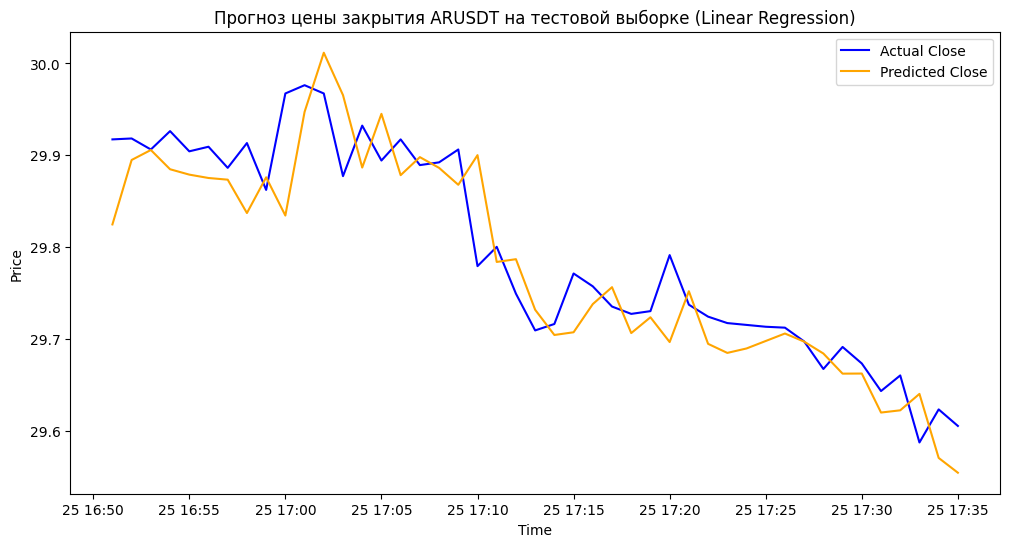

RMSE: 0.05
R squared: 0.82


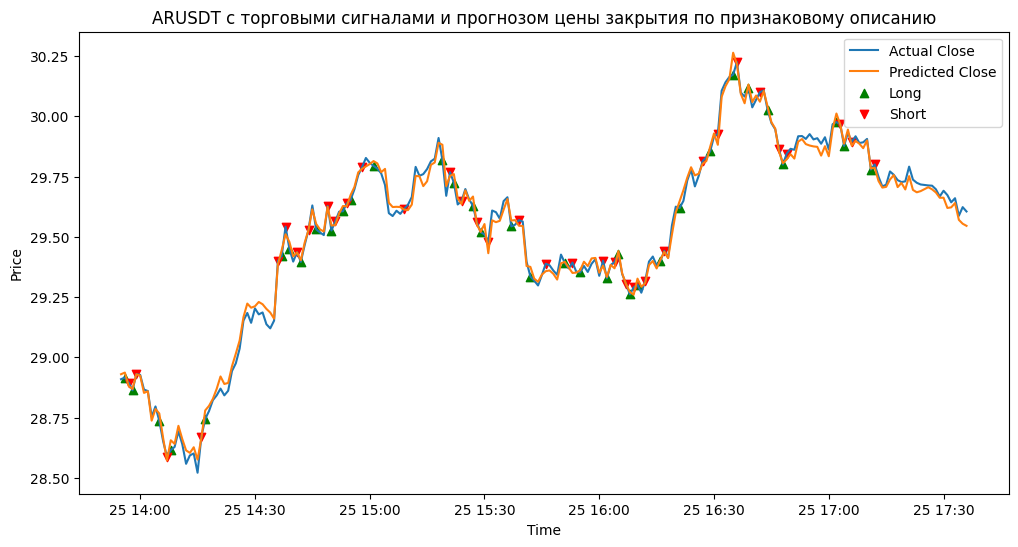

RMSE: 0.06
R squared: 0.97
Общая процентная выручка: 3.81%


In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

shift = 1  # Устанавливаем значение shift на 1
symbol = 'ARUSDT'

# Загрузка данных из CSV
df = pd.read_csv('/content/ARUSDT_1721918198026.csv')

# Преобразование времени в миллисекундах в формат даты
df['Time'] = pd.to_datetime(df['Time'], unit='ms')
df.set_index('Time', inplace=True)

# Создание признаков
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['RSI'] = 100 - (100 / (1 + df['Close'].diff(1).clip(lower=0).rolling(14).mean() /
                          df['Close'].diff(1).clip(upper=0).abs().rolling(14).mean()))

# Удаление строк с NaN
df.dropna(inplace=True)

# Проверка минимального значения Close
print("Минимальное значение Close:", df['Close'].min())

# Подготовка признаков и целевой переменной
features = ['Open', 'High', 'Low', 'Volume', 'MA50', 'MA20', 'RSI']
X = df[features]
y = df['Close'].shift(-shift).dropna()
X = X.iloc[:-shift]

# Разделение данных на обучающую и тестовую выборки
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=False)
y_train = y[:len(X_train)]
y_test = y[len(X_train):]

# Обучение модели линейной регрессии
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Прогнозирование на тестовой выборке
predictions_linear = linear_model.predict(X_test)

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(y_test, predictions_linear))
r2 = r2_score(y_test, predictions_linear)

# Построение графика прогноза на тестовой выборке
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Close', color='blue')
plt.plot(y_test.index, predictions_linear, label='Predicted Close', color='orange')
plt.title(f"Прогноз цены закрытия {symbol} на тестовой выборке (Linear Regression)")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Эффективность модели
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")


predictions_all = linear_model.predict(df[features])
df['Predicted_Close'] = np.nan


df.iloc[:, df.columns.get_loc('Predicted_Close')] = predictions_all

# Генерация торговых сигналов и расчет процентной выручки
position_open = False
df['Signal'] = 0
df['total_return'] = 0.0  # Новый столбец для выручки

entry_price = 0

for i in range(1, len(df)):
    if df['Predicted_Close'].iloc[i] > df['Close'].iloc[i] and not position_open:
        df.loc[df.index[i], 'Signal'] = 1
        entry_price = df['Close'].iloc[i]
        position_open = True
    elif df['Predicted_Close'].iloc[i] < df['Close'].iloc[i] and position_open:
        df.loc[df.index[i], 'Signal'] = -1
        exit_price = df['Close'].iloc[i]
        df.loc[df.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open = False

# Итоговая процентная выручка
total_return = df['total_return'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Close')
plt.plot(df.index, df['Predicted_Close'], label='Predicted Close')
plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], color='green', label='Long', marker='^')
plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], color='red', label='Short', marker='v')
plt.title(f'{symbol} с торговыми сигналами и прогнозом цены закрытия по признаковому описанию')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Расчет метрик RMSE и R squared
true_values = df['Close'].shift(-shift).dropna()
predicted_values = df['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)



# Эффективность стратегии
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
print(f"Общая процентная выручка: {total_return:.2f}%")

Минимальное значение Close: 1.2832


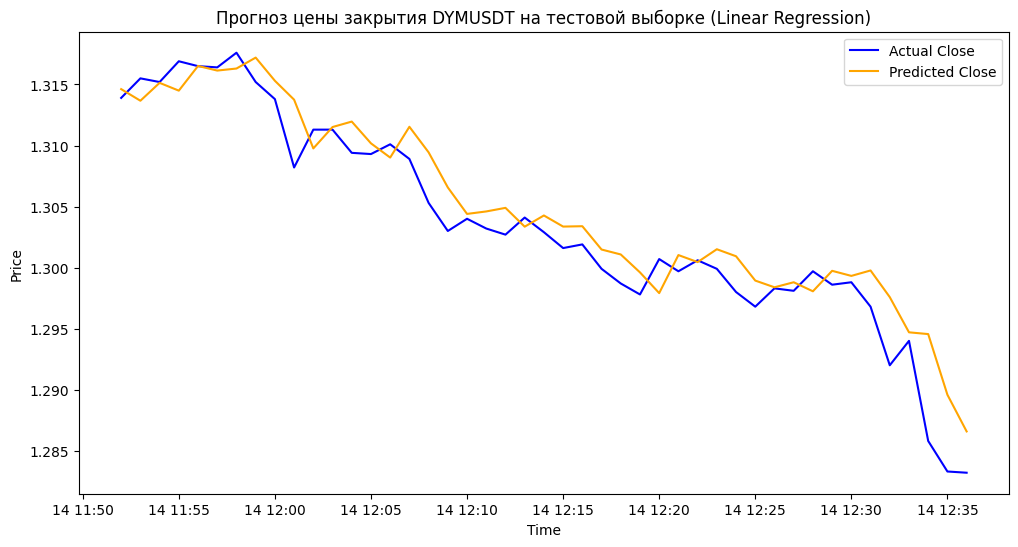

RMSE: 0.00
R squared: 0.90


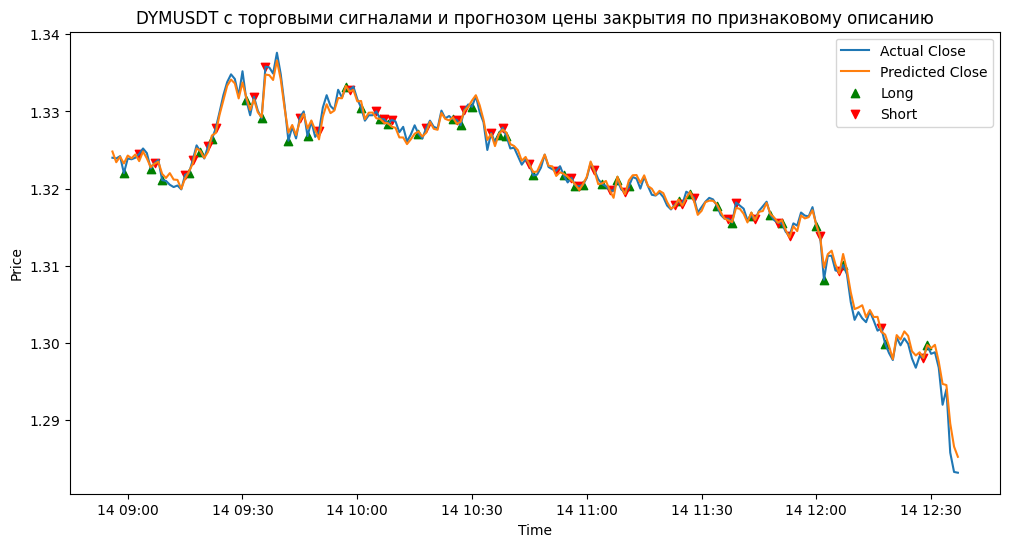

RMSE: 0.00
R squared: 0.97
Общая процентная выручка: -0.12%


In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

shift = 1  # Устанавливаем значение shift на 1
symbol = 'DYMUSDT'

# Загрузка данных из CSV
df = pd.read_csv('/content/DYMUSDT_1720949798938.csv')

# Преобразование времени в миллисекундах в формат даты
df['Time'] = pd.to_datetime(df['Time'], unit='ms')
df.set_index('Time', inplace=True)

# Создание признаков
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['RSI'] = 100 - (100 / (1 + df['Close'].diff(1).clip(lower=0).rolling(14).mean() /
                          df['Close'].diff(1).clip(upper=0).abs().rolling(14).mean()))

# Удаление строк с NaN
df.dropna(inplace=True)

# Проверка минимального значения Close
print("Минимальное значение Close:", df['Close'].min())

# Подготовка признаков и целевой переменной
features = ['Open', 'High', 'Low', 'Volume', 'MA50', 'MA20', 'RSI']
X = df[features]
y = df['Close'].shift(-shift).dropna()
X = X.iloc[:-shift]

# Разделение данных на обучающую и тестовую выборки
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=False)
y_train = y[:len(X_train)]
y_test = y[len(X_train):]

# Обучение модели линейной регрессии
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Прогнозирование на тестовой выборке
predictions_linear = linear_model.predict(X_test)

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(y_test, predictions_linear))
r2 = r2_score(y_test, predictions_linear)

# Построение графика прогноза на тестовой выборке
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Close', color='blue')
plt.plot(y_test.index, predictions_linear, label='Predicted Close', color='orange')
plt.title(f"Прогноз цены закрытия {symbol} на тестовой выборке (Linear Regression)")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Эффективность модели
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")


predictions_all = linear_model.predict(df[features])
df['Predicted_Close'] = np.nan


df.iloc[:, df.columns.get_loc('Predicted_Close')] = predictions_all

# Генерация торговых сигналов и расчет процентной выручки
position_open = False
df['Signal'] = 0
df['total_return'] = 0.0  # Новый столбец для выручки

entry_price = 0

for i in range(1, len(df)):
    if df['Predicted_Close'].iloc[i] > df['Close'].iloc[i] and not position_open:
        df.loc[df.index[i], 'Signal'] = 1
        entry_price = df['Close'].iloc[i]
        position_open = True
    elif df['Predicted_Close'].iloc[i] < df['Close'].iloc[i] and position_open:
        df.loc[df.index[i], 'Signal'] = -1
        exit_price = df['Close'].iloc[i]
        df.loc[df.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open = False

# Итоговая процентная выручка
total_return = df['total_return'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Close')
plt.plot(df.index, df['Predicted_Close'], label='Predicted Close')
plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], color='green', label='Long', marker='^')
plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], color='red', label='Short', marker='v')
plt.title(f'{symbol} с торговыми сигналами и прогнозом цены закрытия по признаковому описанию')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Расчет метрик RMSE и R squared
true_values = df['Close'].shift(-shift).dropna()
predicted_values = df['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)



# Эффективность стратегии
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
print(f"Общая процентная выручка: {total_return:.2f}%")

Минимальное значение Close: 0.00938


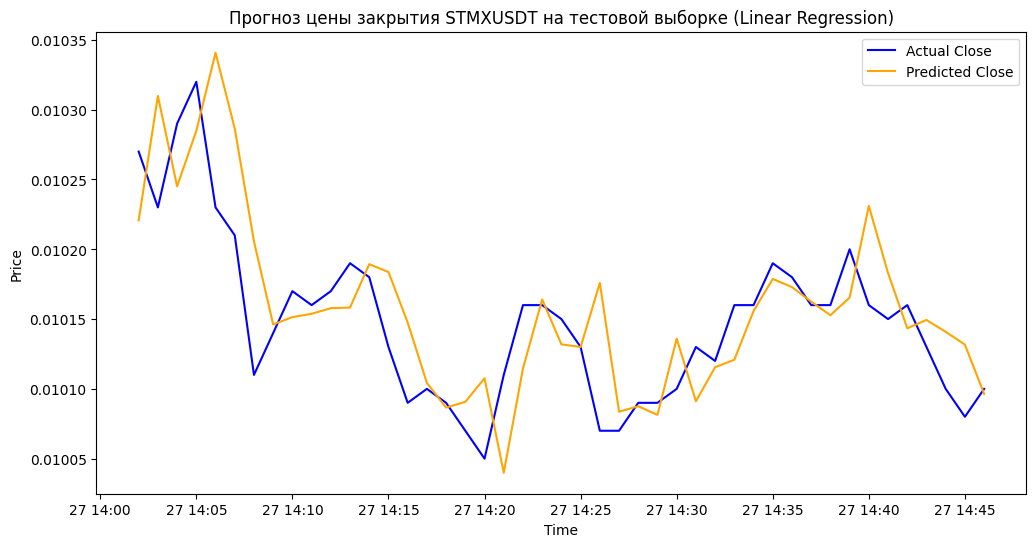

RMSE: 0.00
R squared: 0.43


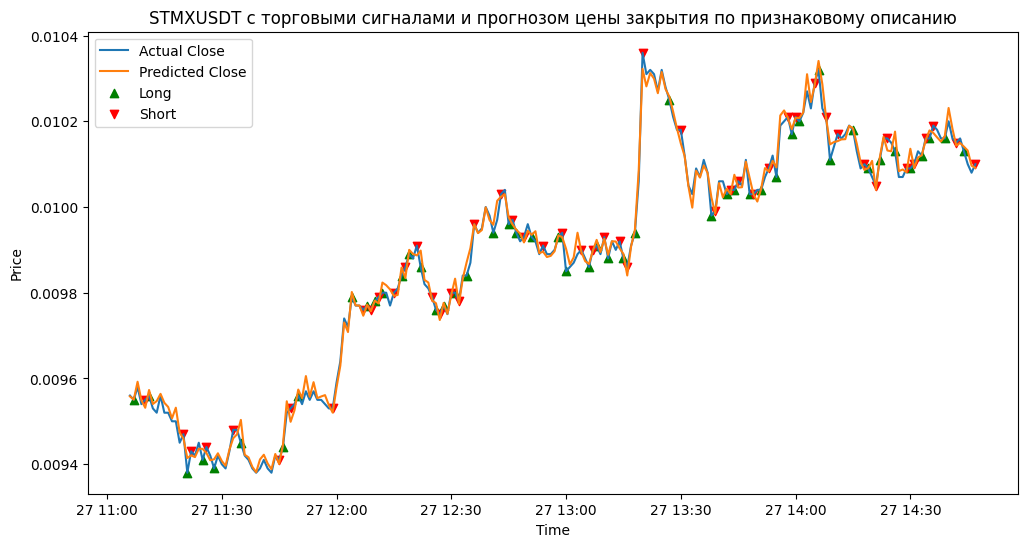

RMSE: 0.00
R squared: 0.97
Общая процентная выручка: 9.76%


In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

shift = 1  # Устанавливаем значение shift на 1
symbol = 'STMXUSDT'

# Загрузка данных из CSV
df = pd.read_csv('/content/STMXUSDT_1722080875736.csv')

# Преобразование времени в миллисекундах в формат даты
df['Time'] = pd.to_datetime(df['Time'], unit='ms')
df.set_index('Time', inplace=True)

# Создание признаков
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['RSI'] = 100 - (100 / (1 + df['Close'].diff(1).clip(lower=0).rolling(14).mean() /
                          df['Close'].diff(1).clip(upper=0).abs().rolling(14).mean()))

# Удаление строк с NaN
df.dropna(inplace=True)

# Проверка минимального значения Close
print("Минимальное значение Close:", df['Close'].min())

# Подготовка признаков и целевой переменной
features = ['Open', 'High', 'Low', 'Volume', 'MA50', 'MA20', 'RSI']
X = df[features]
y = df['Close'].shift(-shift).dropna()
X = X.iloc[:-shift]

# Разделение данных на обучающую и тестовую выборки
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=False)
y_train = y[:len(X_train)]
y_test = y[len(X_train):]

# Обучение модели линейной регрессии
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Прогнозирование на тестовой выборке
predictions_linear = linear_model.predict(X_test)

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(y_test, predictions_linear))
r2 = r2_score(y_test, predictions_linear)

# Построение графика прогноза на тестовой выборке
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Close', color='blue')
plt.plot(y_test.index, predictions_linear, label='Predicted Close', color='orange')
plt.title(f"Прогноз цены закрытия {symbol} на тестовой выборке (Linear Regression)")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Эффективность модели
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")


predictions_all = linear_model.predict(df[features])
df['Predicted_Close'] = np.nan


df.iloc[:, df.columns.get_loc('Predicted_Close')] = predictions_all

# Генерация торговых сигналов и расчет процентной выручки
position_open = False
df['Signal'] = 0
df['total_return'] = 0.0  # Новый столбец для выручки

entry_price = 0

for i in range(1, len(df)):
    if df['Predicted_Close'].iloc[i] > df['Close'].iloc[i] and not position_open:
        df.loc[df.index[i], 'Signal'] = 1
        entry_price = df['Close'].iloc[i]
        position_open = True
    elif df['Predicted_Close'].iloc[i] < df['Close'].iloc[i] and position_open:
        df.loc[df.index[i], 'Signal'] = -1
        exit_price = df['Close'].iloc[i]
        df.loc[df.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open = False

# Итоговая процентная выручка
total_return = df['total_return'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Close')
plt.plot(df.index, df['Predicted_Close'], label='Predicted Close')
plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], color='green', label='Long', marker='^')
plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], color='red', label='Short', marker='v')
plt.title(f'{symbol} с торговыми сигналами и прогнозом цены закрытия по признаковому описанию')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Расчет метрик RMSE и R squared
true_values = df['Close'].shift(-shift).dropna()
predicted_values = df['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)



# Эффективность стратегии
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
print(f"Общая процентная выручка: {total_return:.2f}%")

Минимальное значение Close: 2514.9


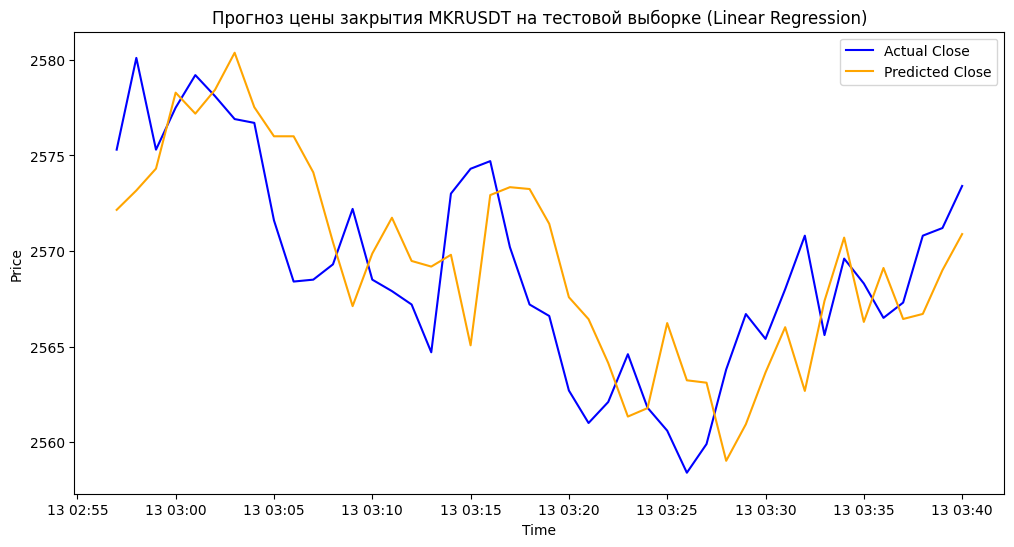

RMSE: 4.07
R squared: 0.44


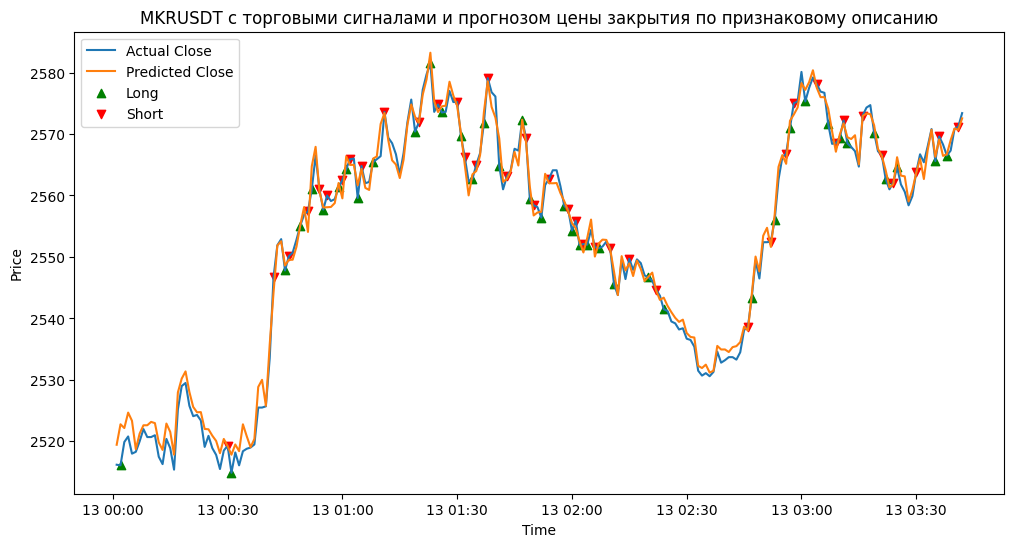

RMSE: 4.93
R squared: 0.93
Общая процентная выручка: 3.79%


In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

shift = 2  # Устанавливаем значение shift на 1
symbol = 'MKRUSDT'

# Загрузка данных из CSV
df = pd.read_csv('/content/MKRUSDT_1720831364647.csv')

# Преобразование времени в миллисекундах в формат даты
df['Time'] = pd.to_datetime(df['Time'], unit='ms')
df.set_index('Time', inplace=True)

# Создание признаков
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['RSI'] = 100 - (100 / (1 + df['Close'].diff(1).clip(lower=0).rolling(14).mean() /
                          df['Close'].diff(1).clip(upper=0).abs().rolling(14).mean()))

# Удаление строк с NaN
df.dropna(inplace=True)

# Проверка минимального значения Close
print("Минимальное значение Close:", df['Close'].min())

# Подготовка признаков и целевой переменной
features = ['Open', 'High', 'Low', 'Volume']#, 'MA50', 'MA20', 'RSI']
X = df[features]
y = df['Close'].shift(-shift).dropna()
X = X.iloc[:-shift]

# Разделение данных на обучающую и тестовую выборки
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=False)
y_train = y[:len(X_train)]
y_test = y[len(X_train):]

# Обучение модели линейной регрессии
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Прогнозирование на тестовой выборке
predictions_linear = linear_model.predict(X_test)

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(y_test, predictions_linear))
r2 = r2_score(y_test, predictions_linear)

# Построение графика прогноза на тестовой выборке
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Close', color='blue')
plt.plot(y_test.index, predictions_linear, label='Predicted Close', color='orange')
plt.title(f"Прогноз цены закрытия {symbol} на тестовой выборке (Linear Regression)")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Эффективность модели
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")


predictions_all = linear_model.predict(df[features])
df['Predicted_Close'] = np.nan


df.iloc[:, df.columns.get_loc('Predicted_Close')] = predictions_all

# Генерация торговых сигналов и расчет процентной выручки
position_open = False
df['Signal'] = 0
df['total_return'] = 0.0  # Новый столбец для выручки

entry_price = 0

for i in range(1, len(df)):
    if df['Predicted_Close'].iloc[i] > df['Close'].iloc[i] and not position_open:
        df.loc[df.index[i], 'Signal'] = 1
        entry_price = df['Close'].iloc[i]
        position_open = True
    elif df['Predicted_Close'].iloc[i] < df['Close'].iloc[i] and position_open:
        df.loc[df.index[i], 'Signal'] = -1
        exit_price = df['Close'].iloc[i]
        df.loc[df.index[i], 'total_return'] = (exit_price - entry_price) / entry_price * 100
        position_open = False

# Итоговая процентная выручка
total_return = df['total_return'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Close')
plt.plot(df.index, df['Predicted_Close'], label='Predicted Close')
plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], color='green', label='Long', marker='^')
plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], color='red', label='Short', marker='v')
plt.title(f'{symbol} с торговыми сигналами и прогнозом цены закрытия по признаковому описанию')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Расчет метрик RMSE и R squared
true_values = df['Close'].shift(-shift).dropna()
predicted_values = df['Predicted_Close'].dropna()

# Убедимся, что длины совпадают
min_length = min(len(true_values), len(predicted_values))
true_values = true_values.iloc[:min_length]
predicted_values = predicted_values.iloc[:min_length]

# Расчет метрик RMSE и R squared
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
r2 = r2_score(true_values, predicted_values)



# Эффективность стратегии
print(f"RMSE: {rmse:.2f}")
print(f"R squared: {r2:.2f}")
print(f"Общая процентная выручка: {total_return:.2f}%")